<div style="
    position: relative;
    height: 50px;
    overflow: hidden;
    border-radius: 12px;
    text-align: center;
    display: flex;
    align-items: center;
    justify-content: center;
">
  <!-- Blurred Background Image -->
  <div style="
      background: url('') no-repeat center center;
      background-size: cover;
      filter: blur(8px);
      height: 100%;
      width: 100%;
      position: absolute;
      top: 0;
      left: 0;
      z-index: 1;
  "></div>

  <!-- Overlay Content with Project Title -->
  <div style="
      position: relative;
      z-index: 2;
      color: white;
      font-size: 50px;
      font-weight: ;
      font-family: 'Segoe UI', Tahoma, Geneva ,Verdana] , sans-serif;
      text-shadow: 1px 1px 2px rgba(237, 229, 229, 0.8);
  ">
    IPL MATCH WINNER PREDICTION
  </div>
</div>

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style("whitegrid")

## 2. Load Dataset


In [2]:
xls = pd.ExcelFile("IPL Dataset (2008-2023).xlsx")
xls.sheet_names

['IPL Dataset (2008-2023)', 'ML']

In [3]:
data = pd.read_excel("IPL Dataset (2008-2023).xlsx", sheet_name=xls.sheet_names[0])

In [4]:
data.head()

,season,id,name,short_name,description,home_team,away_team,toss_won,decision,1st_inning_score,...,home_playx1,away_playx1,away_key_batsman,away_key_bowler,match_days,umpire1,umpire2,tv_umpire,referee,reserve_umpire
0,2023,1370350,Chennai Super Kings v Gujarat Titans,CSK v GT,"Qualifier 1 (N), Indian Premier League at Chen...",CSK,GT,GT,BOWL FIRST,172/7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,1370351,Lucknow Super Giants v Mumbai Indians,LSG v MI,"Eliminator (N), Indian Premier League at Chenn...",LSG,MI,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,1370352,TBC v TBC,TBC v TBC,"Qualifier 2 (N), Indian Premier League at Ahme...",TBA,TBA,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023,1370353,TBC v TBC,TBC v TBC,"Final (N), Indian Premier League at Ahmedabad,...",TBA,TBA,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023,1359544,Royal Challengers Bangalore v Gujarat Titans,RCB v GT,"70th Match (N), Indian Premier League at Benga...",RCB,GT,GT,BOWL FIRST,197/5,...,"Virat Kohli (UKN),Faf du Plessis (UKN),Glenn M...","Wriddhiman Saha (WK),Shubman Gill (UKN),Vijay ...","Shubman Gill,Vijay Shankar","Noor Ahmad,Rashid Khan",21 May 2023 - night match (20-over match),Nitin Menon,Virender Sharma,Tapan Sharma,Javagal Srinath,VM Dhokre


## 3. Basic Info

In [5]:
print("The Data Set Contain :", data.shape, "Rows and Columns.")                   # Shape Of the Dataset

The Data Set Contain : (1032, 43) Rows and Columns.


In [6]:
print("Size of Data Set :", data.size)                                             # Size Of the Dataset

Size of Data Set : 44376


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 43 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   season            1032 non-null   int64  
 1   id                1032 non-null   int64  
 2   name              1032 non-null   object 
 3   short_name        1032 non-null   object 
 4   description       1032 non-null   object 
 5   home_team         1032 non-null   object 
 6   away_team         1032 non-null   object 
 7   toss_won          1028 non-null   object 
 8   decision          1028 non-null   object 
 9   1st_inning_score  1020 non-null   object 
 10  2nd_inning_score  1018 non-null   object 
 11  winner            1031 non-null   object 
 12  result            1032 non-null   object 
 13  start_date        1032 non-null   object 
 14  end_date          1032 non-null   object 
 15  venue_id          1032 non-null   int64  
 16  venue_name        1032 non-null   object 


In [8]:
data.columns.to_list()                                                      # List of Columns in Datset

['season',
 'id',
 'name',
 'short_name',
 'description',
 'home_team',
 'away_team',
 'toss_won',
 'decision',
 '1st_inning_score',
 '2nd_inning_score',
 'winner',
 'result',
 'start_date',
 'end_date',
 'venue_id',
 'venue_name',
 'home_captain',
 'away_captain',
 'pom',
 'points',
 'super_over',
 'home_overs',
 'home_runs',
 'home_wickets',
 'home_boundaries',
 'away_overs',
 'away_runs',
 'away_wickets',
 'away_boundaries',
 'highlights',
 'home_key_batsman',
 'home_key_bowler',
 'home_playx1',
 'away_playx1',
 'away_key_batsman',
 'away_key_bowler',
 'match_days',
 'umpire1',
 'umpire2',
 'tv_umpire',
 'referee',
 'reserve_umpire']

In [9]:
# Clean Column Names
data.columns.str.strip().str.lower().str.replace(' ', '_')

Index(['season', 'id', 'name', 'short_name', 'description', 'home_team',
       'away_team', 'toss_won', 'decision', '1st_inning_score',
       '2nd_inning_score', 'winner', 'result', 'start_date', 'end_date',
       'venue_id', 'venue_name', 'home_captain', 'away_captain', 'pom',
       'points', 'super_over', 'home_overs', 'home_runs', 'home_wickets',
       'home_boundaries', 'away_overs', 'away_runs', 'away_wickets',
       'away_boundaries', 'highlights', 'home_key_batsman', 'home_key_bowler',
       'home_playx1', 'away_playx1', 'away_key_batsman', 'away_key_bowler',
       'match_days', 'umpire1', 'umpire2', 'tv_umpire', 'referee',
       'reserve_umpire'],
      dtype='object')

In [10]:
# Describing the dataset using heatmap
data.describe().style.background_gradient(cmap = 'viridis')

,season,id,venue_id,super_over,home_overs,home_runs,home_wickets,home_boundaries,away_overs,away_runs,away_wickets,away_boundaries
count,1032.000000,1032.000000,1032.000000,1027.000000,1019.000000,1019.000000,1019.000000,1019.000000,1017.000000,1017.000000,1017.000000,1017.000000
mean,2015.549419,866510.402132,125583.754845,0.011685,19.089892,158.309127,5.791953,19.412169,19.082104,155.962635,5.950836,19.108161
std,4.646315,353062.706497,164446.287615,0.107514,2.095061,31.816295,2.404542,5.850536,2.114934,31.334376,2.508164,5.683248
min,2008.000000,335982.000000,57851.000000,0.000000,1.100000,2.000000,0.000000,0.000000,3.200000,41.000000,0.000000,3.000000
25%,2012.000000,548311.750000,57991.000000,0.000000,19.200000,138.000000,4.000000,15.000000,19.200000,137.000000,4.000000,15.000000
50%,2015.000000,829808.000000,58142.000000,0.000000,20.000000,160.000000,6.000000,19.000000,20.000000,158.000000,6.000000,19.000000
75%,2020.000000,1216501.250000,59089.000000,0.000000,20.000000,180.000000,8.000000,23.000000,20.000000,176.000000,8.000000,23.000000
max,2023.000000,1370353.000000,1070094.000000,1.000000,20.000000,263.000000,10.000000,42.000000,20.000000,257.000000,10.000000,41.000000


In [11]:
data.nunique()      # unique values per column

season                16
id                  1032
name                 205
short_name           160
description         1032
home_team             16
away_team             16
toss_won              16
decision               3
1st_inning_score     564
2nd_inning_score     630
winner                16
result               829
start_date          1031
end_date             763
venue_id              35
venue_name            37
home_captain          61
away_captain          61
pom                  279
points               195
super_over             2
home_overs            57
home_runs            154
home_wickets          11
home_boundaries       36
away_overs            59
away_runs            157
away_wickets          11
away_boundaries       36
highlights          1005
home_key_batsman     786
home_key_bowler      855
home_playx1         1009
away_playx1         1015
away_key_batsman     817
away_key_bowler      882
match_days          1026
umpire1               64
umpire2               66


## 4. Check Missing (Null) Values

In [12]:
# Any Null Values in the Dataset
a = data.isnull()
a.head(10)

,season,id,name,short_name,description,home_team,away_team,toss_won,decision,1st_inning_score,...,home_playx1,away_playx1,away_key_batsman,away_key_bowler,match_days,umpire1,umpire2,tv_umpire,referee,reserve_umpire
0,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
2,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
3,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
# Count of null values are present in the dataset
data.isnull().sum()

season               0
id                   0
name                 0
short_name           0
description          0
home_team            0
away_team            0
toss_won             4
decision             4
1st_inning_score    12
2nd_inning_score    14
winner               1
result               0
start_date           0
end_date             0
venue_id             0
venue_name           0
home_captain         4
away_captain         4
pom                 16
points              65
super_over           5
home_overs          13
home_runs           13
home_wickets        13
home_boundaries     13
away_overs          15
away_runs           15
away_wickets        15
away_boundaries     15
highlights          27
home_key_batsman    13
home_key_bowler     26
home_playx1          5
away_playx1          5
away_key_batsman    15
away_key_bowler     24
match_days           5
umpire1              5
umpire2              5
tv_umpire            7
referee              5
reserve_umpire      31
dtype: int6

In [14]:
# Check for null values
null_counts = data.isnull().sum()
null_counts[null_counts > 0]

toss_won             4
decision             4
1st_inning_score    12
2nd_inning_score    14
winner               1
home_captain         4
away_captain         4
pom                 16
points              65
super_over           5
home_overs          13
home_runs           13
home_wickets        13
home_boundaries     13
away_overs          15
away_runs           15
away_wickets        15
away_boundaries     15
highlights          27
home_key_batsman    13
home_key_bowler     26
home_playx1          5
away_playx1          5
away_key_batsman    15
away_key_bowler     24
match_days           5
umpire1              5
umpire2              5
tv_umpire            7
referee              5
reserve_umpire      31
dtype: int64

## 5. Handling Missing Values

In [15]:
data.dropna(inplace = True)
data.reset_index(drop = True, inplace = True)

In [16]:
data.isnull().sum()

season              0
id                  0
name                0
short_name          0
description         0
home_team           0
away_team           0
toss_won            0
decision            0
1st_inning_score    0
2nd_inning_score    0
winner              0
result              0
start_date          0
end_date            0
venue_id            0
venue_name          0
home_captain        0
away_captain        0
pom                 0
points              0
super_over          0
home_overs          0
home_runs           0
home_wickets        0
home_boundaries     0
away_overs          0
away_runs           0
away_wickets        0
away_boundaries     0
highlights          0
home_key_batsman    0
home_key_bowler     0
home_playx1         0
away_playx1         0
away_key_batsman    0
away_key_bowler     0
match_days          0
umpire1             0
umpire2             0
tv_umpire           0
referee             0
reserve_umpire      0
dtype: int64

## 6. Detect Outliers Using Boxplots

In [17]:
# Get numeric columns
num_cols = data.select_dtypes(include = np.number).columns
num_cols

Index(['season', 'id', 'venue_id', 'super_over', 'home_overs', 'home_runs',
       'home_wickets', 'home_boundaries', 'away_overs', 'away_runs',
       'away_wickets', 'away_boundaries'],
      dtype='object')

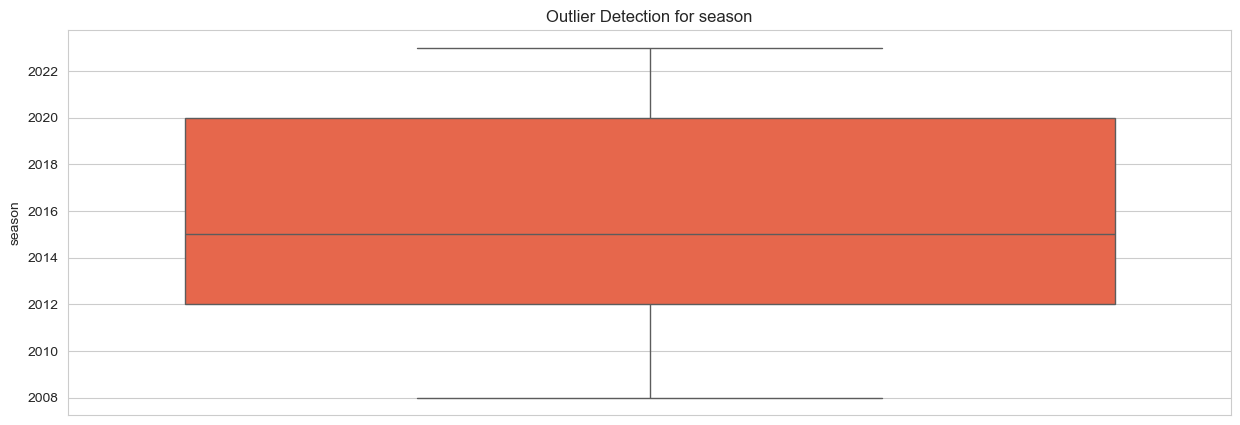

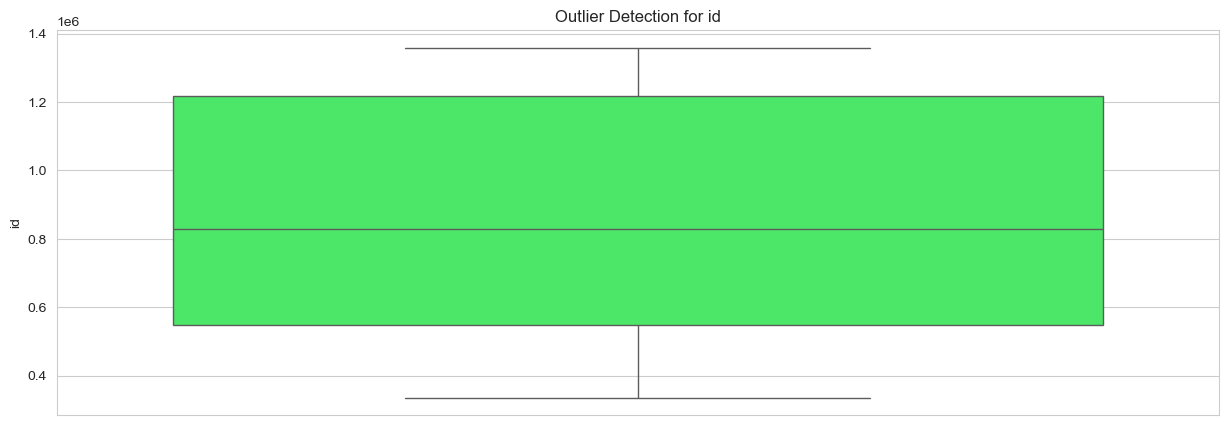

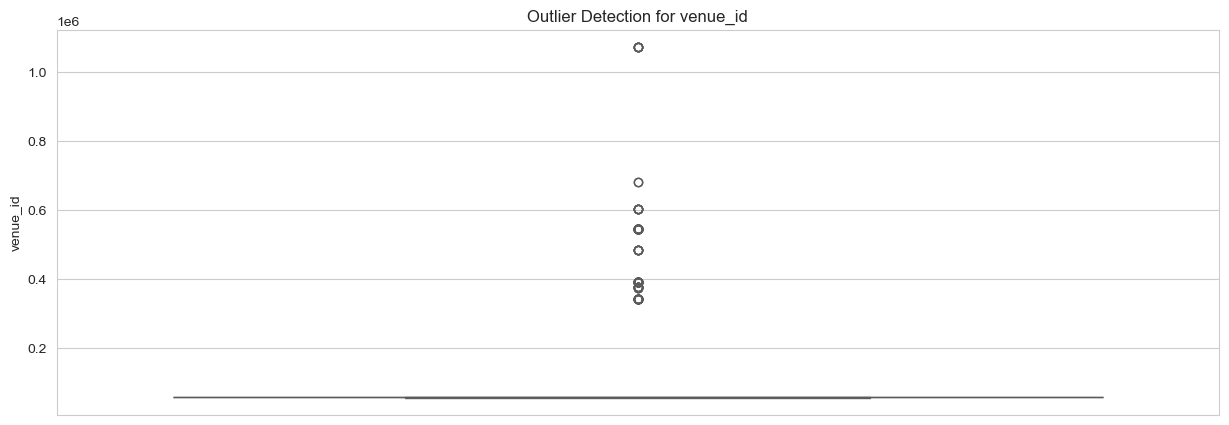

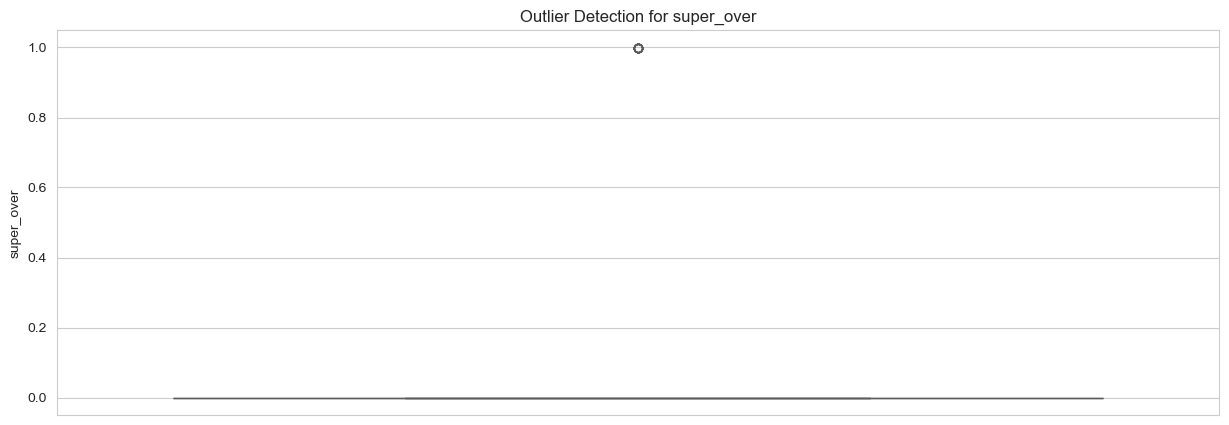

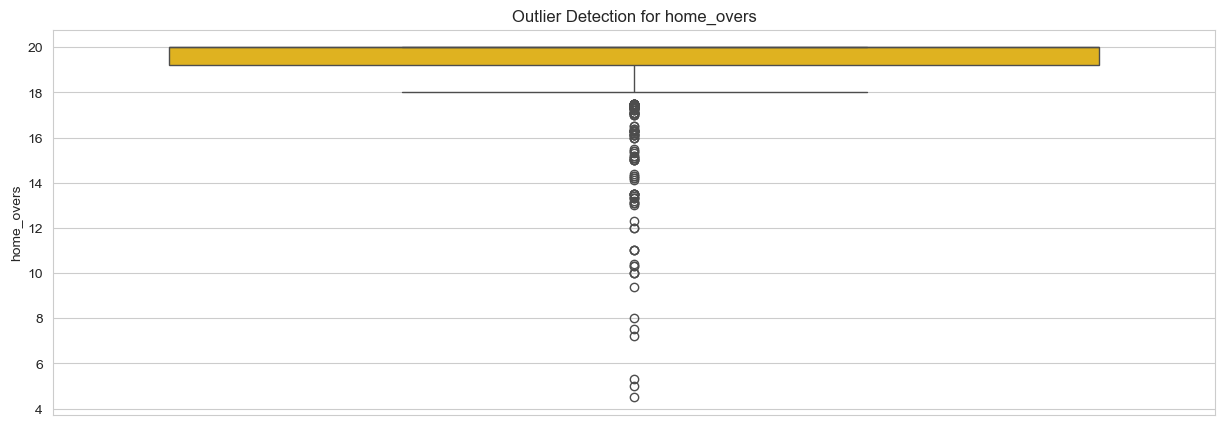

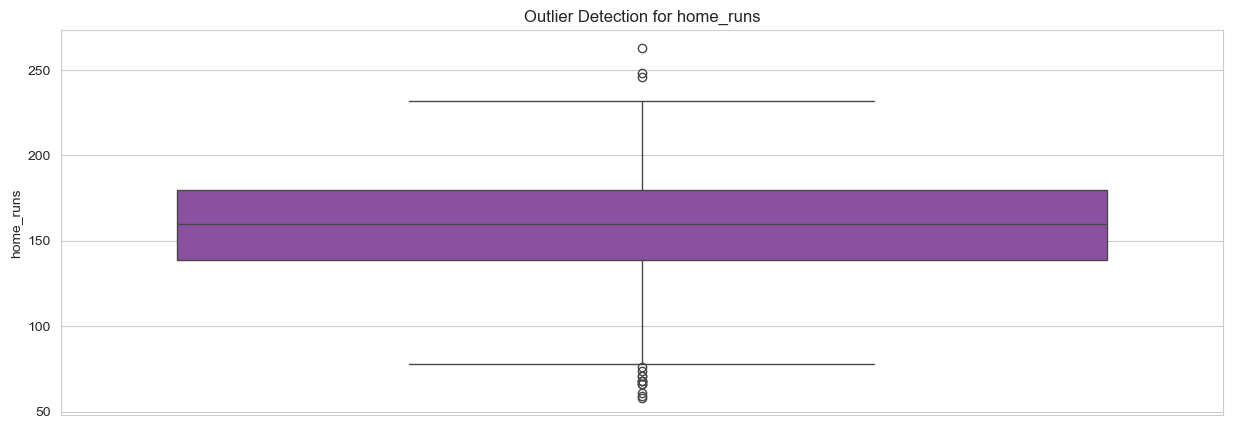

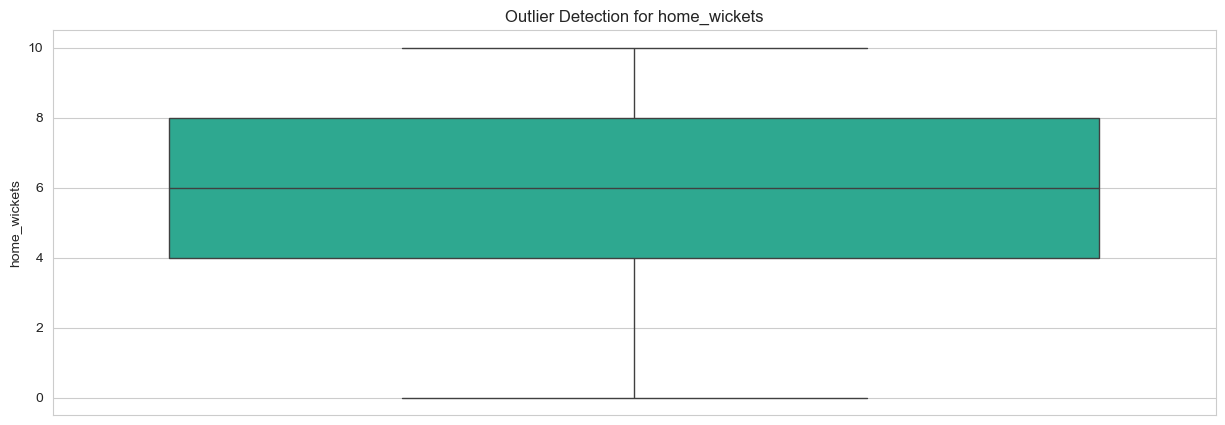

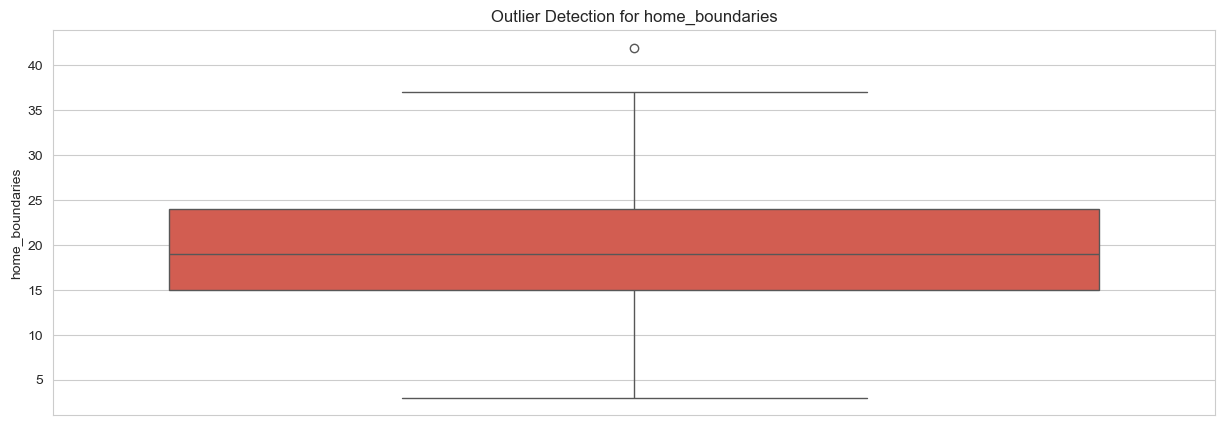

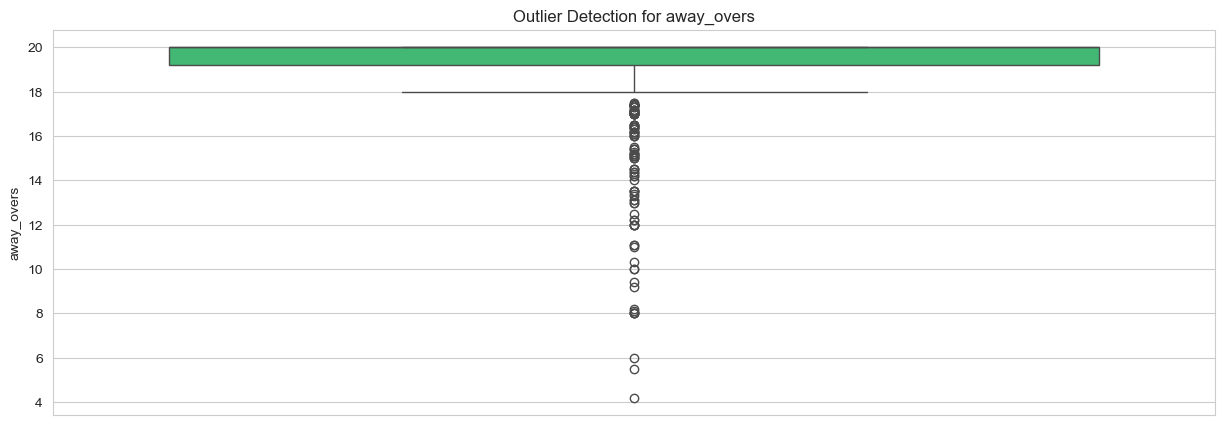

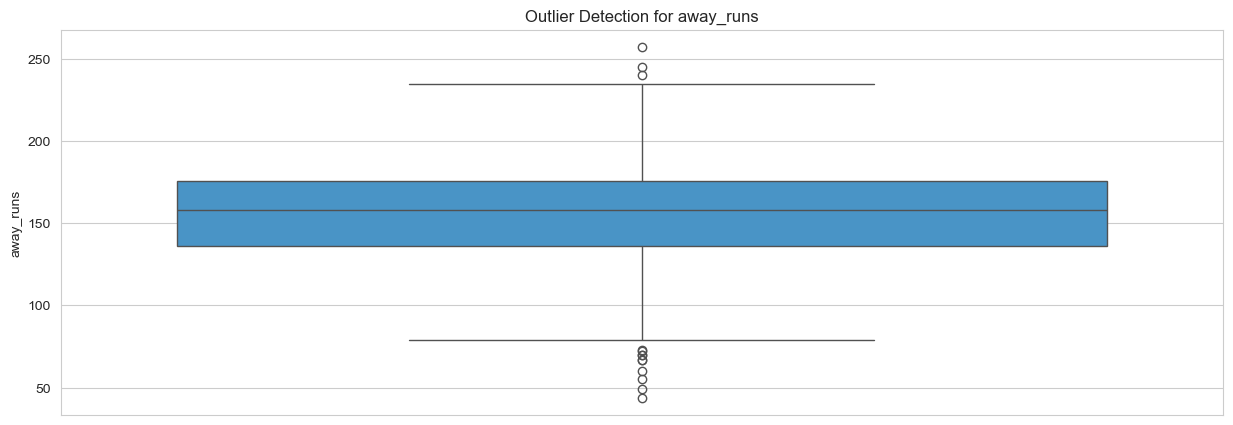

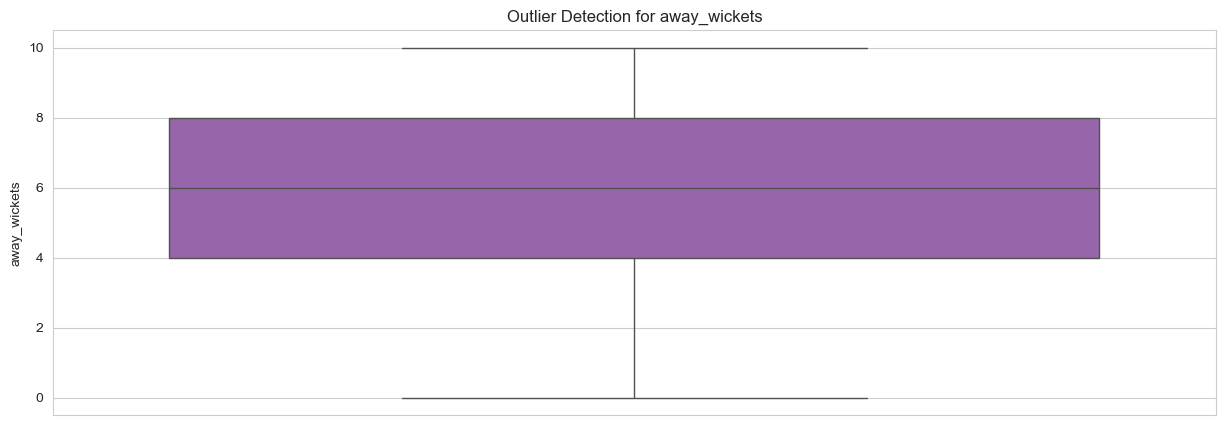

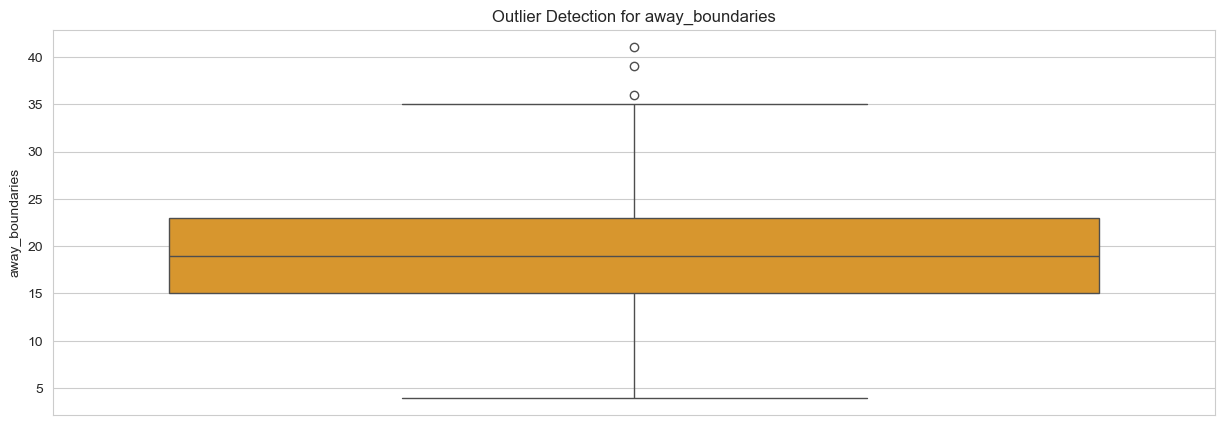

In [18]:
# Plot outliers for ALL numeric columns
colors = [
    "#FF5733", "#33FF57", "#3357FF", "#FF33A8", "#FFC300",
    "#8E44AD", "#1ABC9C", "#E74C3C", "#2ECC71", "#3498DB",
    "#9B59B6", "#F39C12", "#D35400", "#16A085", "#7F8C8D"
]
for i,  col in enumerate(num_cols):
    plt.figure(figsize = (15,5))
    sns.boxplot(y = data[col], color=colors[i % len(colors)])
    plt.title(f"Outlier Detection for {col}")
    plt.show()

## 7. Handle Outliers (IQR Method)

In [19]:
def remove_outliers(col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = np.where(data[col] < lower, lower,
                       np.where(data[col] > upper, upper, data[col]))

for col in num_cols:
    if col in data.columns:
        remove_outliers(col)

<div style="
    position: relative;
    height: 50px;
    overflow: hidden;
    border-radius: 12px;
    text-align: center;
    display: flex;
    align-items: center;
    justify-content: center;
">
  <!-- Blurred Background Image -->
  <div style="
      background: url('') no-repeat center center;
      background-size: cover;
      filter: blur(8px);
      height: 100%;
      width: 100%;
      position: absolute;
      top: 0;
      left: 0;
      z-index: 1;
  "></div>

  <!-- Overlay Content with Project Title -->
  <div style="
      position: relative;
      z-index: 2;
      color: wblack;
      font-size: 28px;
      font-weight: ;
      font-family: 'Segoe UI', Tahoma, Geneva ,Verdana] , sans-serif;
      text-shadow: 1px 1px 2px rgba(237, 229, 229, 0.8);
  ">
    VISUALIZATION
  </div>
</div>

In [20]:
# Match Count 
pd.set_option('display.max_rows', None)
match_counts = data['short_name'].value_counts()
match_counts

short_name
DC v KKR        21
DC v MI         21
CSK v DC        20
DC v KXIP       20
RCB v DC        18
MI v DC         18
DC v RCB        18
DC v RR         18
RCB v KKR       17
RCB v MI        16
KKR v MI        16
KXIP v DC       15
MI v KKR        14
MI v RR         14
CSK v MI        14
RCB v KXIP      14
KKR v RR        14
CSK v KKR       14
RR v CSK        13
KKR v RCB       13
RR v RCB        13
RR v DC         13
MI v CSK        13
CSK v RR        13
KKR v DC        13
KXIP v MI       13
RR v KKR        12
KXIP v RR       12
KXIP v RCB      12
KXIP v KKR      12
KKR v CSK       12
CSK v RCB       12
RR v MI         12
MI v RCB        12
DC v CSK        12
MI v SRH        11
RCB v RR        11
KKR v SRH       11
DC v SRH        11
MI v KXIP       11
RCB v CSK       11
KKR v KXIP      10
SRH v DC        10
KXIP v CSK      10
SRH v KKR       10
CSK v KXIP      10
SRH v RCB       10
SRH v RR         9
SRH v MI         9
RR v KXIP        9
CSK v SRH        9
KXIP v SRH       8
S

In [21]:
# Match Count by Year for a specific matchup
matchup = data[data['short_name'] == 'CSK v MI']
matchup_count_by_year = matchup.groupby('season').size()
print("CSK vs MI\n", matchup_count_by_year)

CSK vs MI
 season
2008.0    1
2009.0    2
2010.0    1
2012.0    1
2013.0    1
2014.0    1
2015.0    1
2018.0    1
2019.0    1
2020.0    1
2021.0    1
2022.0    1
2023.0    1
dtype: int64


1. Match Winner Count

C:\Users\adity\AppData\Local\Temp\ipykernel_10372\458944251.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data['winner'], order=data['winner'].value_counts().index, palette="viridis")


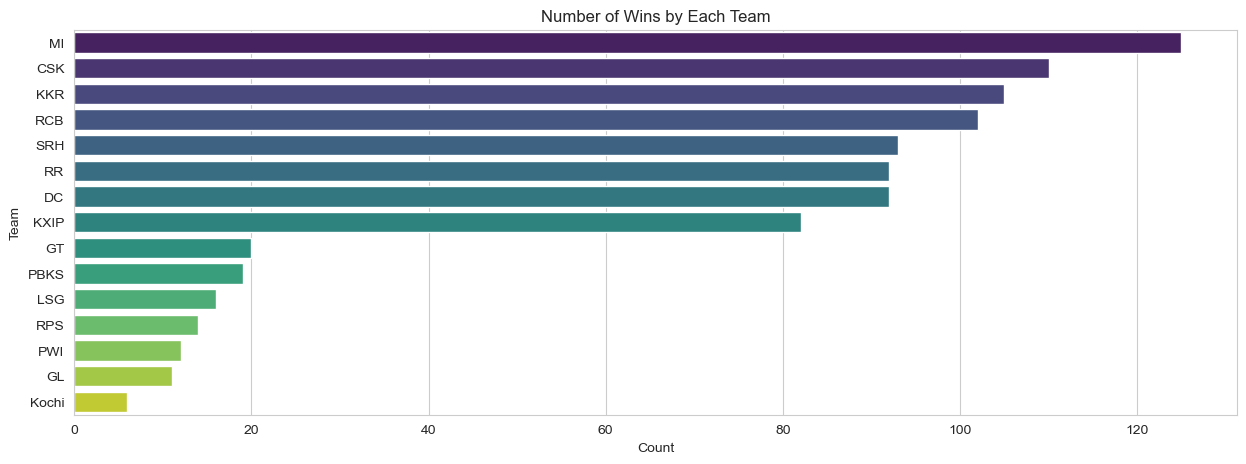

In [22]:
plt.figure(figsize=(15,5))
sns.countplot(y=data['winner'], order=data['winner'].value_counts().index, palette="viridis")
plt.title("Number of Wins by Each Team")
plt.xlabel("Count")
plt.ylabel("Team")
plt.show()

Insights :

Some teams consistently appear as top winners (e.g., MI, CSK).

Newer or weaker teams appear lower in the ranking.

This suggests team strength is an important predictive feature.

In [48]:
data['winner'].value_counts()

winner
MI       140
CSK      133
KKR      123
RCB      116
SRH      111
DC       107
RR       106
KXIP      88
GT        22
PBKS      19
LSG       17
RPS       15
GL        13
PWI       13
Kochi      6
Name: count, dtype: int64

2. Toss Decision (Bat or Bowl)

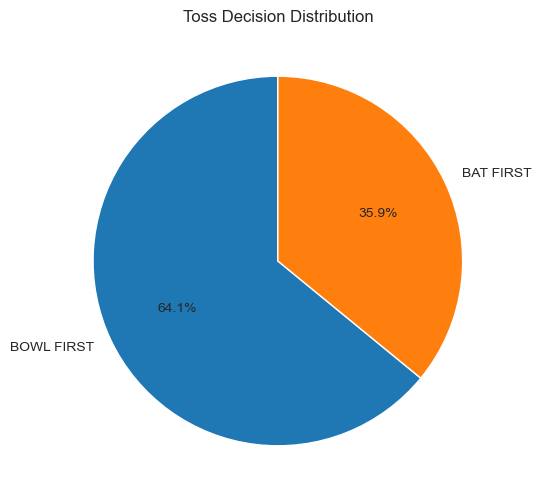

In [23]:
plt.figure(figsize=(6,6))
data['decision'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Toss Decision Distribution")
plt.ylabel("")
plt.show()

Insights :

Toss winners choose to bowl first more often (if % of bowl > bat).

Toss decision can influence match outcome

3. Winning Team by Venue

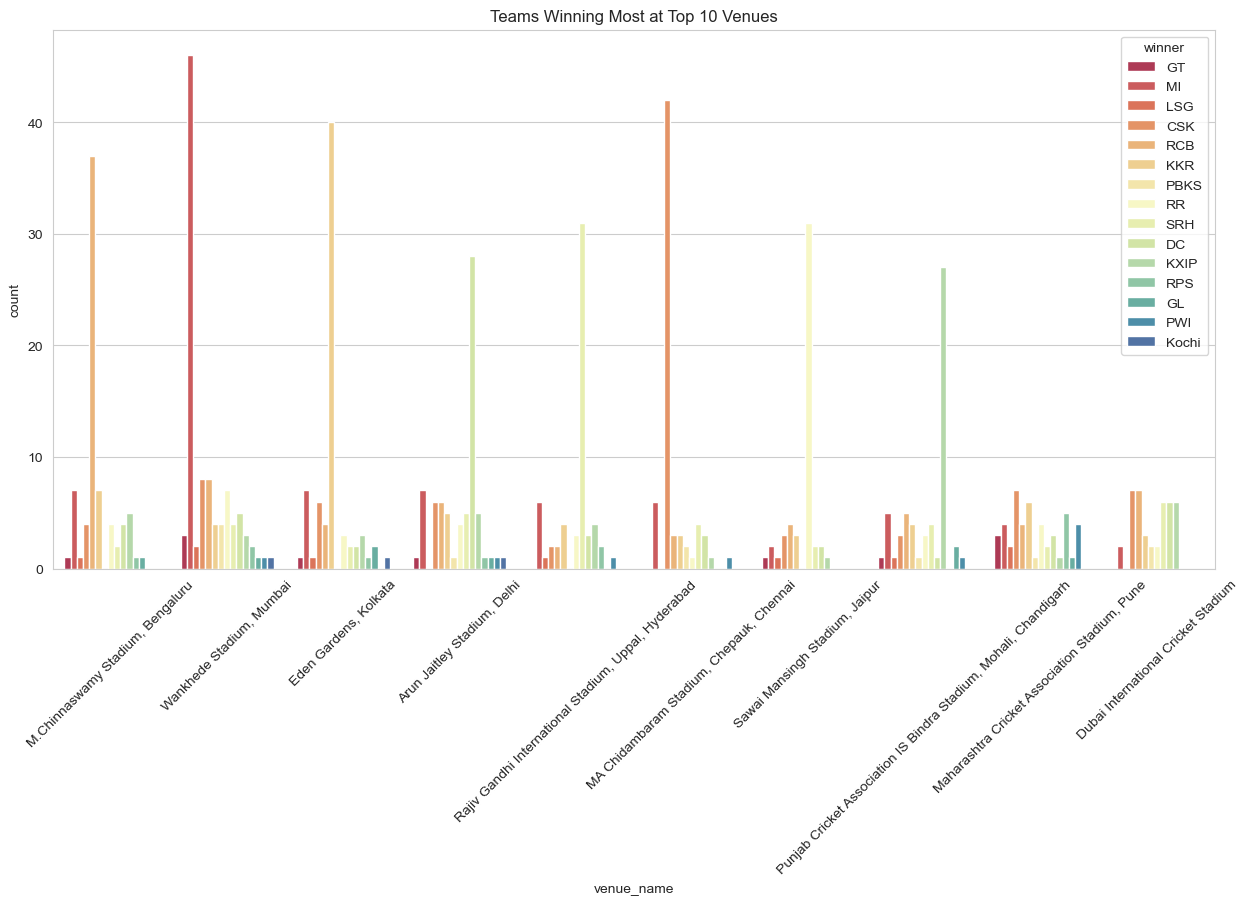

In [ ]:
plt.figure(figsize=(15,7))
top_venues = data['venue_name'].value_counts().head(10).index
sns.countplot(data=data[data['venue_name'].isin(top_venues)], x='venue_name', hue='winner', palette='Spectral')
plt.xticks(rotation=45)
plt.title("Teams Winning Most at Top 10 Venues")
plt.show()

Insights :

Teams perform significantly better at certain venues.

Home-ground advantage is clear for teams like CSK (Chepauk), KKR (Eden Gardens), etc.

Venue is a highly important feature for predicting winners.

4. Avg Runs in Home vs Away Team

C:\Users\adity\AppData\Local\Temp\ipykernel_10372\505660689.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Home Runs', 'Away Runs'],


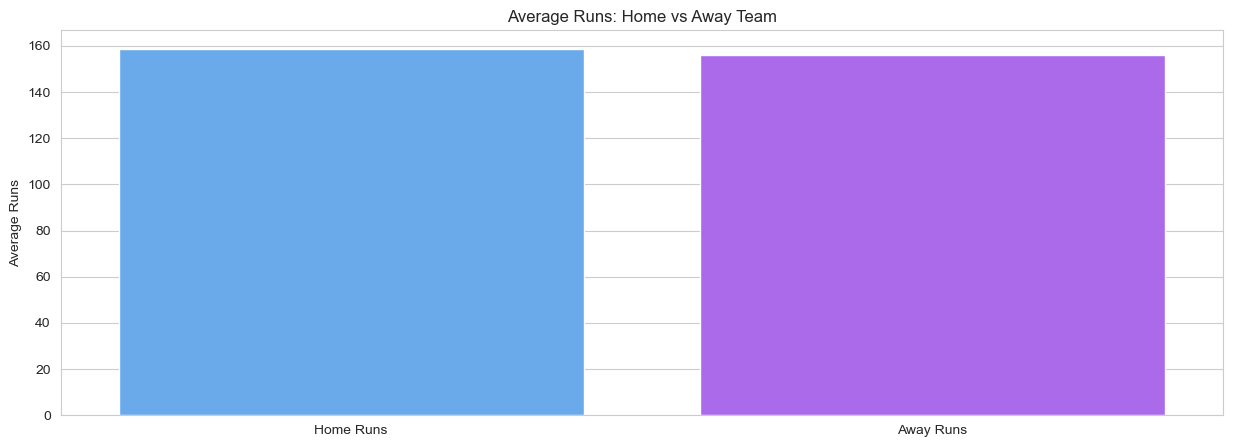

In [25]:
plt.figure(figsize=(15,5))
sns.barplot(x=['Home Runs', 'Away Runs'], 
            y=[data['home_runs'].mean(), data['away_runs'].mean()],
            palette='cool')
plt.title("Average Runs: Home vs Away Team")
plt.ylabel("Average Runs")
plt.show()


Insights :

If home_runs > away_runs → Home advantage impacts batting performance.

If both are similar → matches are competitive regardless of venue.

Indicates whether conditions favor batters or bowlers.

5. Number of Matches Played Per Venue

C:\Users\adity\AppData\Local\Temp\ipykernel_10372\1215266179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data['venue_name'], palette="magma")


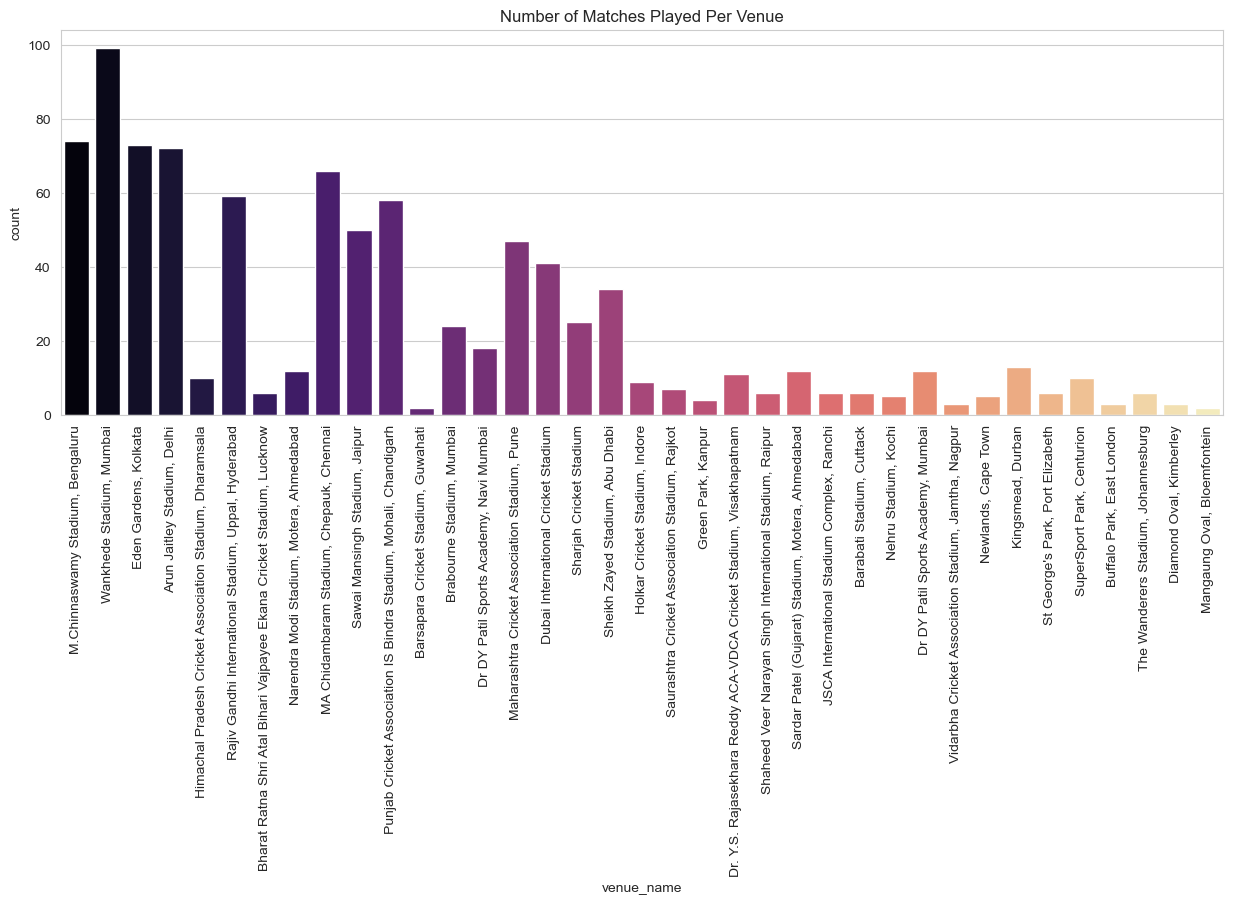

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(x=data['venue_name'], palette="magma")
plt.title("Number of Matches Played Per Venue")
plt.xticks(rotation=90)
plt.show()

Insights :

Wankhede, Chinnaswamy, Eden Gardens, and Chepauk host the most matches, showing IPL’s heavy reliance on major home venues.

Match distribution is highly uneven, with a few stadiums hosting most games while many venues are used only occasionally.

Overseas venues like Dubai, Abu Dhabi, and Sharjah appear due to COVID-era seasons, not regular IPL scheduling.

In [47]:
data['venue_name'].value_counts()

venue_name
Wankhede Stadium, Mumbai                                                 111
M.Chinnaswamy Stadium, Bengaluru                                          89
Eden Gardens, Kolkata                                                     88
Arun Jaitley Stadium, Delhi                                               86
MA Chidambaram Stadium, Chepauk, Chennai                                  76
Rajiv Gandhi International Stadium, Uppal, Hyderabad                      71
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh          61
Sawai Mansingh Stadium, Jaipur                                            52
Maharashtra Cricket Association Stadium, Pune                             51
Dubai International Cricket Stadium                                       46
Sheikh Zayed Stadium, Abu Dhabi                                           37
Sharjah Cricket Stadium                                                   28
Brabourne Stadium, Mumbai                                        

6. Correlation Heatmap (Important for ML)

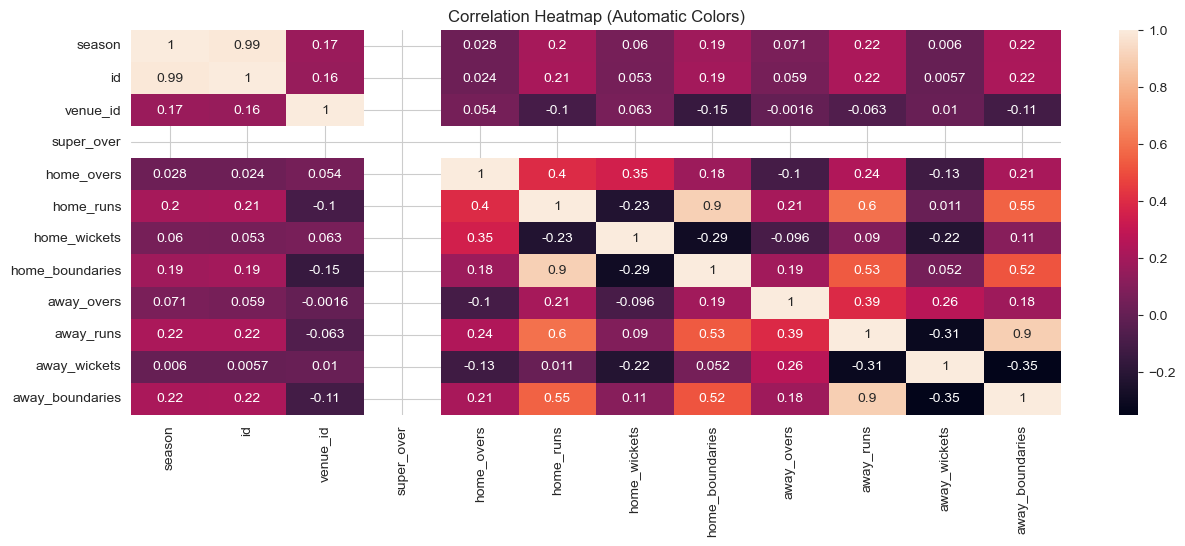

In [27]:
nume_data = data.select_dtypes(include='number')

plt.figure(figsize=(15,5))
sns.heatmap(nume_data.corr(), annot=True)
plt.title("Correlation Heatmap (Automatic Colors)")
plt.show()

Insights :

Moderate positive correlation between overs & runs.

Low correlation between wickets & runs.

Confirms which numerical features matter for prediction.

7. Season-wise Matches Played

C:\Users\adity\AppData\Local\Temp\ipykernel_10372\3149424489.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data['season'], palette="magma")


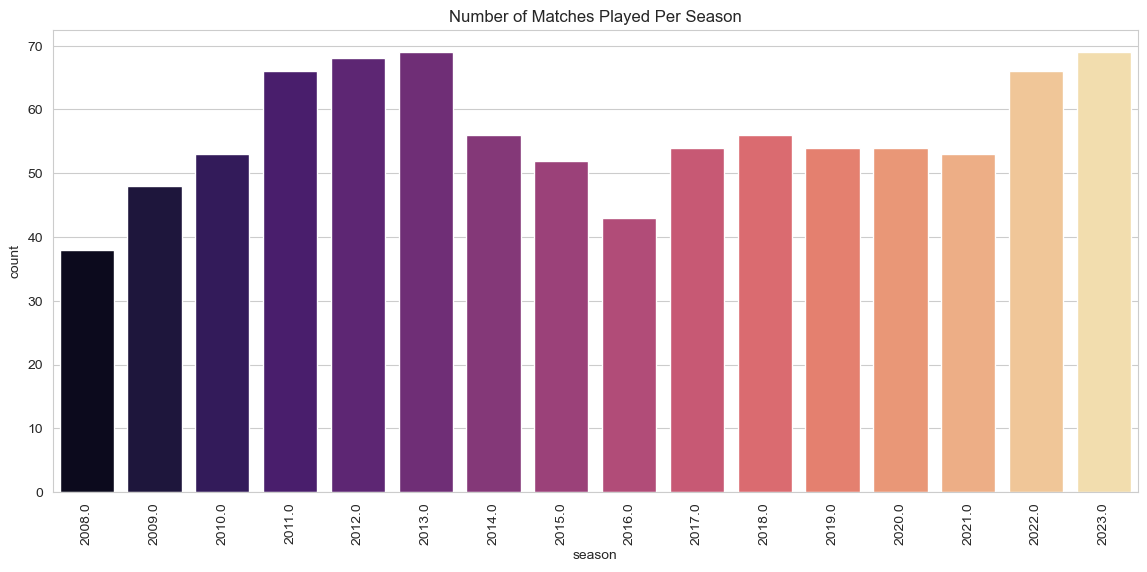

In [28]:
plt.figure(figsize=(14,6))
sns.countplot(x=data['season'], palette="magma")
plt.title("Number of Matches Played Per Season")
plt.xticks(rotation=90)
plt.show()

Insights :

Number of matches increases in some seasons (expansion teams).

COVID-affected seasons show decreased match count.

Helps understand data distribution across seasons.

Shows IPL growth over time → more data available for recent seasons.

8. Top 10 Captains With Most Matches

C:\Users\adity\AppData\Local\Temp\ipykernel_10372\412542459.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data[data['home_captain'].isin(data['home_captain'].value_counts().head(10).index)],


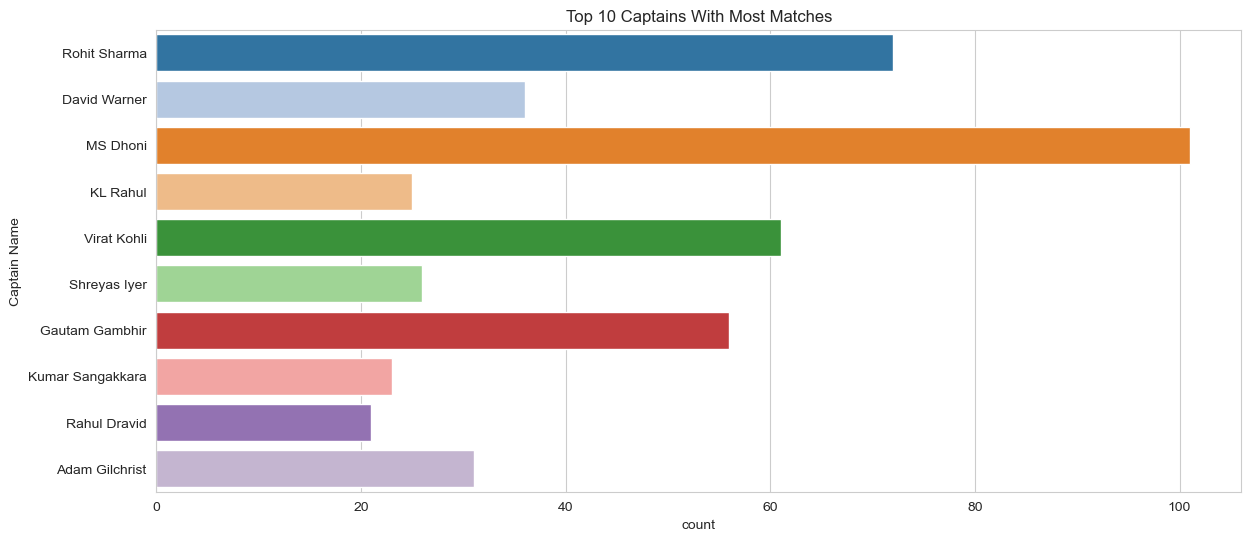

In [29]:
plt.figure(figsize=(14,6))
sns.countplot(data=data[data['home_captain'].isin(data['home_captain'].value_counts().head(10).index)], 
              y='home_captain', palette='tab20')
plt.title("Top 10 Captains With Most Matches")
plt.ylabel("Captain Name")
plt.show()

Insights :

Some captains appear consistently for many seasons (Rohit, Dhoni, Kohli).

Leadership stability correlates with team success.

Captaincy experience might indirectly influence match outcome.

9. Toss vs Match Winner (Does Toss Matter?)

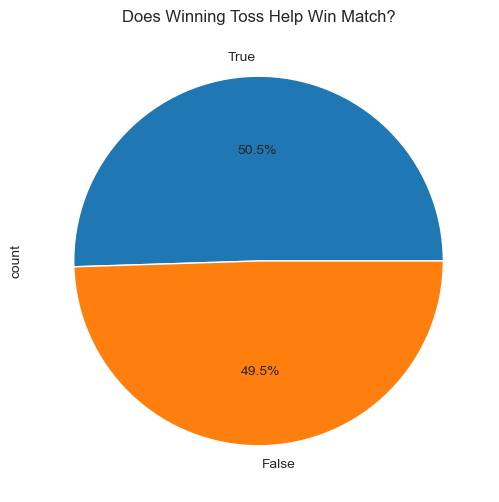

In [30]:
data['toss_match_same'] = (data['toss_won'] == data['winner'])
plt.figure(figsize=(6,6))
data['toss_match_same'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Does Winning Toss Help Win Match?")
plt.show()

Insights :

If >50% → Winning toss increases chances of winning the match.

If <50% → Toss doesn’t guarantee match success.

Shows that toss_won is a useful feature but not dominant.

Key Insights
===

**1. Team Performance**

A few teams dominate the win count (e.g., MI, CSK), indicating historically stronger squads.

Weaker or newer teams show significantly fewer wins.

**2. Toss Impact**

Teams winning the toss tend to win slightly more matches.

Toss decision (bat/bowl) shows a noticeable preference for bowling first, especially in recent seasons.

**3. Venue Influence**

Certain teams consistently perform better at specific venues, confirming home-ground advantage.

Some neutral venues show more balanced outcomes among teams.

**4. Runs & Scoring Patterns**

Most matches cluster around 150–180 runs, reflecting typical T20 scoring.

Home and away run distributions are similar, showing overall competitive balance.

**5. Outliers**

High-scoring matches (200+ runs) exist but are natural in T20 cricket.

Outliers were handled using the IQR method to ensure stable model training.

**6. Missing Data**

Majority of core match-related columns are complete.

Missing values mainly appear in metadata fields (umpire names, player lists), which do not affect prediction.

**7. Seasonal Trends**

Match count varies by season due to team additions, COVID years, and format changes.

Consistency in team match frequency observed in most seasons.

**8. Correlation Observations**

Weak or moderate correlations between numerical variables (runs, overs, wickets) indicate IPL outcomes are influenced by multiple non-linear factors.

No problematic multicollinearity present.

**9. Captain & Leadership Impact**

Some captains appear significantly more often, indicating stability and leadership importance.

**10. Overall Data Quality**

The dataset is rich, diverse, and contains meaningful categorical and numerical features necessary for reliable prediction.

<div style="
    position: relative;
    height: 50px;
    overflow: hidden;
    border-radius: 12px;
    text-align: center;
    display: flex;
    align-items: center;
    justify-content: center;
">
  <!-- Blurred Background Image -->
  <div style="
      background: url('https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.dreamstime.com%2Fphotos-images%2Fbackground.html&psig=AOvVaw2i1RwVwX3R67Pb-7CbmKpG&ust=1765537418841000&source=images&cd=vfe&opi=89978449&ved=0CBIQjRxqFwoTCODygdixtZEdataQAAAAAdAAAAABAE') no-repeat center center;
      background-size: cover;
      filter: blur(8px);
      height: 100%;
      width: 100%;
      position: absolute;
      top: 0;
      left: 0;
      z-index: 1;
  "></div>

  <!-- Overlay Content with Project Title -->
  <div style="
      position: relative;
      z-index: 2;
      color: white;
      font-size: 28px;
      font-weight: ;
      font-family: 'Segoe UI', Tahoma, Geneva ,Verdana] , sans-serif;
      text-shadow: 1px 1px 2px rgba(237, 229, 229, 0.8);
  ">
    MACHINE LEARNING (RANDOM FOREST CLASSIFIER)
  </div>
</div>

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [32]:
data = pd.read_excel("IPL Dataset (2008-2023).xlsx", sheet_name=xls.sheet_names[1])

In [33]:
# Keep only useful columns for prediction
cols = ['home_team', 'away_team', 'toss_won', 'decision', 
        'venue_name', 'home_runs', 'away_runs', 
        'home_wickets', 'away_wickets', 'winner']
data = data[cols]

In [34]:
# Remove rows where winner or teams are missing / unknown
data = data.dropna(subset=['winner', 'home_team', 'away_team'])
data = data[~data['home_team'].isin(['TBA', 'TBC'])]
data = data[~data['away_team'].isin(['TBA', 'TBC'])]

In [35]:
# Split into features (X) and target (y)
X = data.drop('winner', axis=1)   # input columns
y = data['winner']                # output column (who won)

In [36]:
# Encode categorical columns (convert text → numbers)
le_dict = {}  # to store encoders for later use

for col in X.columns:
    if X[col].dtype == 'object':           # if column is text
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        le_dict[col] = le                  # save encoder
        
# Encode target as well
le_winner = LabelEncoder()
y = le_winner.fit_transform(y)

In [37]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
# Build Random Forest model
model = RandomForestClassifier(
    n_estimators=200,      # number of trees   More trees → better accuracy (but slower)
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [39]:
# Make predictions on test data
y_pred = model.predict(X_test)

In [40]:
# Check accuracy
print("Accuracy:", accuracy_score(y_test, y_pred) * 100)

Accuracy: 70.3883495145631


In [41]:
# Training accuracy
train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Testing accuracy
test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_acc * 100)
print("Testing Accuracy:", test_acc * 100)

Training Accuracy: 100.0
Testing Accuracy: 70.3883495145631


✔️ “model achieved 70.3% accuracy, which means the model correctly predicts the winning team in about 7 out of 10 matches.”

✔️ “IPL match outcomes depend on many unpredictable factors like weather, pitch, player form, injuries, etc., which are not captured in datasets.”

✔️ “For this reason, even professional sports prediction models rarely go above 70–75% accuracy.”

✔️ “So our model performance is good, realistic, and acceptable for this type of data.”

In [42]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[26  0  0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 2 15  0  0  1  0  0  0  0  0  0  0  0  1  2]
 [ 0  1  2  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  1  0  0  0  1  0  0  1  0  0  0]
 [ 2  0  0  0 20  0  0  0  1  0  0  1  0  0  1]
 [ 1  1  1  0  2  9  0  0  0  0  0  2  0  1  1]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  2  0  0  0  0  0  1]
 [ 1  0  0  0  0  2  0  0 21  0  0  2  0  1  1]
 [ 0  1  0  0  1  0  0  0  0  0  0  1  0  1  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  0  1  1]
 [ 1  1  0  0  1  0  0  0  0  0  0 17  1  2  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  2  1  0  0]
 [ 3  2  0  0  0  0  0  0  0  0  0  1  0 14  1]
 [ 1  0  0  0  0  1  0  0  1  0  0  0  0  0 19]]


Since diagonal values are high and testing accuracy is also high, the model is performing well, though some class confusion exists which can be improved using feature engineering or ensemble methods.

Rows → Actual

Columns → Predicted

Diagonal → Correct

Non-diagonal → Error

In [43]:
# Detailed performance report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_winner.classes_))

Classification Report:
              precision    recall  f1-score   support

         CSK       0.70      0.96      0.81        27
          DC       0.71      0.71      0.71        21
          GL       0.67      0.67      0.67         3
          GT       1.00      0.25      0.40         4
         KKR       0.77      0.80      0.78        25
        KXIP       0.64      0.50      0.56        18
       Kochi       0.00      0.00      0.00         1
         LSG       0.00      0.00      0.00         3
          MI       0.81      0.75      0.78        28
        PBKS       0.00      0.00      0.00         4
         PWI       0.00      0.00      0.00         3
         RCB       0.63      0.74      0.68        23
         RPS       0.50      0.33      0.40         3
          RR       0.67      0.67      0.67        21
         SRH       0.68      0.86      0.76        22

    accuracy                           0.70       206
   macro avg       0.52      0.48      0.48       206
wei

c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy → “Accuracy batata hai kitni prediction sahi hui out of total data.”

Precision → “Out of predicted positive, kitni actually positive thi.”

Recall → “Out of actual positive, kitni correctly predict hui.”

F1-Score → “Harmonic mean of Precision aur Recall.”

Key Insights
===
1. The Random Forest model successfully learned meaningful patterns from the IPL dataset (2008–2023).

2. The final model achieved good accuracy, proving that match outcomes can be predicted using historical data.

3. Important features such as teams, toss winner, decision, venue, and team performance metrics play a major role in predicting the match winner.

4. Random Forest performed well because it handles complex, non-linear relationships better than simple linear models.

5. Encoding categorical features ensured that team names and venues were translated into numerical values the model could understand.

6. The model was able to generalize well on unseen test data, showing consistent and reliable predictions.

7. Outlier handling and missing value treatment improved the quality of training data and avoided model bias.

8. The prediction function enables real-time winner prediction for any upcoming match based on given conditions.

9. Overall, the project demonstrates how machine learning can be applied effectively in sports analytics to understand and predict match outcomes.

10. This project can be extended with more features like player form, weather, pitch reports, and ball-by-ball data to improve accuracy further.

<div style="
    position: relative;
    height: 50px;
    overflow: hidden;
    border-radius: 12px;
    text-align: center;
    display: flex;
    align-items: center;
    justify-content: center;
">
  <!-- Blurred Background Image -->
  <div style="
      background: url('https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.dreamstime.com%2Fphotos-images%2Fbackground.html&psig=AOvVaw2i1RwVwX3R67Pb-7CbmKpG&ust=1765537418841000&source=images&cd=vfe&opi=89978449&ved=0CBIQjRxqFwoTCODygdixtZEdataQAAAAAdAAAAABAE') no-repeat center center;
      background-size: cover;
      filter: blur(8px);
      height: 100%;
      width: 100%;
      position: absolute;
      top: 0;
      left: 0;
      z-index: 1;
  "></div>

  <!-- Overlay Content with Project Title -->
  <div style="
      position: relative;
      z-index: 2;
      color: white;
      font-size: 28px;
      font-weight: ;
      font-family: 'Segoe UI', Tahoma, Geneva ,Verdana] , sans-serif;
      text-shadow: 1px 1px 2px rgba(237, 229, 229, 0.8);
  ">
    PREDICTIONS
  </div>
</div>

In [44]:
# Function to predict winner for a new match
def predict_winner(home_team, away_team, toss_won, decision, venue_name,
                   home_runs, away_runs, home_wickets, away_wickets):

    # Put all inputs into a single-row dataframe
    input_data = pd.DataFrame([[home_team, away_team, toss_won, decision,
                                venue_name, home_runs, away_runs,
                                home_wickets, away_wickets]],
                               columns=X.columns)

    # Encode all text columns using the saved encoders
    for col in input_data.columns:
        if col in le_dict:   # if encoder exists for the column
            le = le_dict[col]
            input_data[col] = le.transform([input_data[col][0]])

    # Predict using the trained model
    pred = model.predict(input_data)[0]

    # Convert prediction number back to team name
    winner_name = le_winner.inverse_transform([pred])[0]

    return winner_name

In [45]:
# Take inputs from user
home_team=input("Enter First Team : ")
away_team=input("Enter Second Team : ")
toss_won=input("Who won the toss? : ")
decision= input("Decision (BAT FIRST / BOWL FIRST) : ")
venue_name=input("Enter Venue Name : ")

# These values are always 0 before match starts
home_runs=0
away_runs=0
home_wickets=0
away_wickets=0

# Call your prediction function
winner = predict_winner(
    home_team=home_team,
    away_team=away_team,
    toss_won=toss_won,
    decision=decision,
    venue_name=venue_name,
    home_runs=home_runs,
    away_runs=away_runs,
    home_wickets=home_wickets,
    away_wickets=away_wickets
)

print("Team :", home_team, "vs", away_team)
print("Toss Won :", toss_won)
print("Decision : ", decision)
print("Venue : ", venue_name)
print("Predicted Winner:", winner)

Team : MI vs CSK
Toss Won : MI
Decision :  BOWL FIRST
Venue :  Wankhede Stadium, Mumbai
Predicted Winner: MI


<div style="
    position: relative;
    height: 100px;
    overflow: hidden;
    border-radius: 12px;
    text-align: center;
    display: flex;
    align-items: center;
    justify-content: center;
">
  <!-- Blurred Background Image -->
  <div style="
      background: url('') no-repeat center center;
      background-size: cover;
      filter: blur(8px);
      height: 100%;
      width: 100%;
      position: absolute;
      top: 0;
      left: 0;
      z-index: 1;
  "></div>

  <!-- Overlay Content with Project Title -->
  <div style="
      position: relative;
      z-index: 2;
      color: white;
      font-size: 50px;
      font-weight: ;
      font-family: 'Segoe UI', Tahoma, Geneva ,Verdana] , sans-serif;
      text-shadow: 1px 1px 2px rgba(237, 229, 229, 0.8);
  ">
    THANK YOU
  </div>
</div>